# 🌿 Satellite Vegetation Health Classification with YOLO26

**Training-course final project — Google Colab**

### Project idea
Classify a Sentinel-2 satellite image patch as:

- **healthy** vegetation
- **stressed** vegetation

We use **Ultralytics YOLO26n Classification** because it is small and simple enough for Colab.

> **Important scientific limitation:** EuroSAT does **not** contain true “healthy/stressed” labels.  
> In this beginner project, we create **proxy labels from NDVI** using Sentinel-2 Red and NIR bands. Higher NDVI is treated as healthier vegetation and lower NDVI as more stressed vegetation. This is a demonstration project, not a field-validated crop-diagnosis system.

### Simple workflow

`EuroSAT multispectral → keep vegetation classes → calculate NDVI → create healthy/stressed folders → train YOLO26n-cls → evaluate → predict → export ONNX`


## 1. Setup

In Colab, select **Runtime → Change runtime type → T4 GPU** if available.


In [1]:
#!/usr/bin/env python
# Uninstall existing ultralytics and Pillow to ensure a clean slate
!pip uninstall -y ultralytics Pillow

# Ensure setuptools is compatible with torch, then upgrade pip and wheel
!pip install setuptools==69.0.3
!pip install --upgrade pip wheel

# Install the latest stable version of Pillow first. This is crucial as Pillow 10.3.0+
# is needed for Python 3.13 compatibility. By not pinning the version, we let pip
# find the latest compatible version that has a wheel or builds successfully.
!pip -q install Pillow

# Then install ultralytics. It should use the already installed, hopefully compatible Pillow version.
!pip -q install ultralytics datasets scikit-learn

from ultralytics import YOLO
from datasets import load_dataset
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random, shutil, os

print("Setup complete.")

Found existing installation: ultralytics 8.4.153
Uninstalling ultralytics-8.4.153:
  Successfully uninstalled ultralytics-8.4.153
Found existing installation: pillow 12.3.0
Uninstalling pillow-12.3.0:
  Successfully uninstalled pillow-12.3.0
Setup complete.


## 2. Download the satellite dataset

We use **EuroSAT**, based on Sentinel-2 satellite images.  
The original EuroSAT project is available on GitHub: `phelber/EuroSAT`.

For an easy Colab download, this notebook uses a public Hugging Face mirror of the **13-band multispectral** data.

We only keep vegetation-related land-cover classes:
- AnnualCrop
- Forest
- HerbaceousVegetation
- Pasture
- PermanentCrop


In [2]:
# Public mirror of EuroSAT multispectral Sentinel-2 data
ds = load_dataset("giswqs/EuroSAT_MS", split="train")

print(ds)
print("Columns:", ds.column_names)


README.md:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

data/train-00000-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  314MB            

data/train-00000-of-00005.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  319MB            

data/train-00001-of-00005.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/18880 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5405 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2713 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label', 'filename'],
    num_rows: 18880
})
Columns: ['image', 'label', 'filename']


## 3. Create healthy/stressed proxy labels using NDVI

NDVI is:

**NDVI = (NIR - Red) / (NIR + Red)**

For Sentinel-2:
- Red = B04
- NIR = B08

To keep the course project simple, we calculate the **mean NDVI** for each vegetation image.  
Then we use the **median NDVI of our selected samples** as the split:

- NDVI ≥ median → **healthy**
- NDVI < median → **stressed**

This creates balanced classes, but remember these are **proxy labels**, not expert ground-truth stress labels.


In [3]:
# Keep the notebook fast for a training course.
# Increase MAX_IMAGES later if you want a larger experiment.
MAX_IMAGES = 4000

vegetation_classes = {
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Pasture", "PermanentCrop"
}

samples = []

for item in ds:
    # The mirror provides the original filename, e.g. AnnualCrop/...
    class_name = item["filename"].split("/")[0]
    if class_name not in vegetation_classes:
        continue

    img = np.asarray(item["image"], dtype=np.float32)  # expected shape: (13, 64, 64)

    red = img[3]   # B04
    nir = img[7]   # B08
    ndvi = (nir - red) / (nir + red + 1e-6)
    mean_ndvi = float(np.nanmean(ndvi))

    samples.append((img, mean_ndvi))

    if len(samples) >= MAX_IMAGES:
        break

ndvi_values = np.array([x[1] for x in samples])
threshold = float(np.median(ndvi_values))

print("Vegetation images:", len(samples))
print("NDVI median threshold:", round(threshold, 3))


Vegetation images: 4000
NDVI median threshold: 0.501


## 4. Convert Sentinel-2 patches to RGB and make YOLO folders

YOLO image classification expects folders like:

```text
vegetation_dataset/
  train/
    healthy/
    stressed/
  val/
    healthy/
    stressed/
  test/
    healthy/
    stressed/
```

We convert Sentinel-2 B04/B03/B02 to an RGB image and split the data 70% / 15% / 15%.


In [4]:
root = Path("/content/vegetation_dataset")
if root.exists():
    shutil.rmtree(root)

for split in ["train", "val", "test"]:
    for label in ["healthy", "stressed"]:
        (root / split / label).mkdir(parents=True, exist_ok=True)

def to_rgb(img13):
    # Sentinel-2: B04=red, B03=green, B02=blue
    rgb = np.stack([img13[3], img13[2], img13[1]], axis=-1)
    # Simple percentile stretch for visualization/training
    lo, hi = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)
    return (rgb * 255).astype(np.uint8)

random.seed(42)
indices = list(range(len(samples)))
random.shuffle(indices)

n = len(indices)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

split_indices = {
    "train": indices[:train_end],
    "val": indices[train_end:val_end],
    "test": indices[val_end:]
}

for split, ids in split_indices.items():
    for j, idx in enumerate(ids):
        img13, mean_ndvi = samples[idx]
        label = "healthy" if mean_ndvi >= threshold else "stressed"
        rgb = to_rgb(img13)
        Image.fromarray(rgb).save(root / split / label / f"{split}_{j:05d}.jpg")

for split in ["train", "val", "test"]:
    print(split,
          "healthy =", len(list((root/split/"healthy").glob("*.jpg"))),
          "stressed =", len(list((root/split/"stressed").glob("*.jpg"))))


train healthy = 1379 stressed = 1421
val healthy = 310 stressed = 290
test healthy = 311 stressed = 289


## 5. View example satellite images

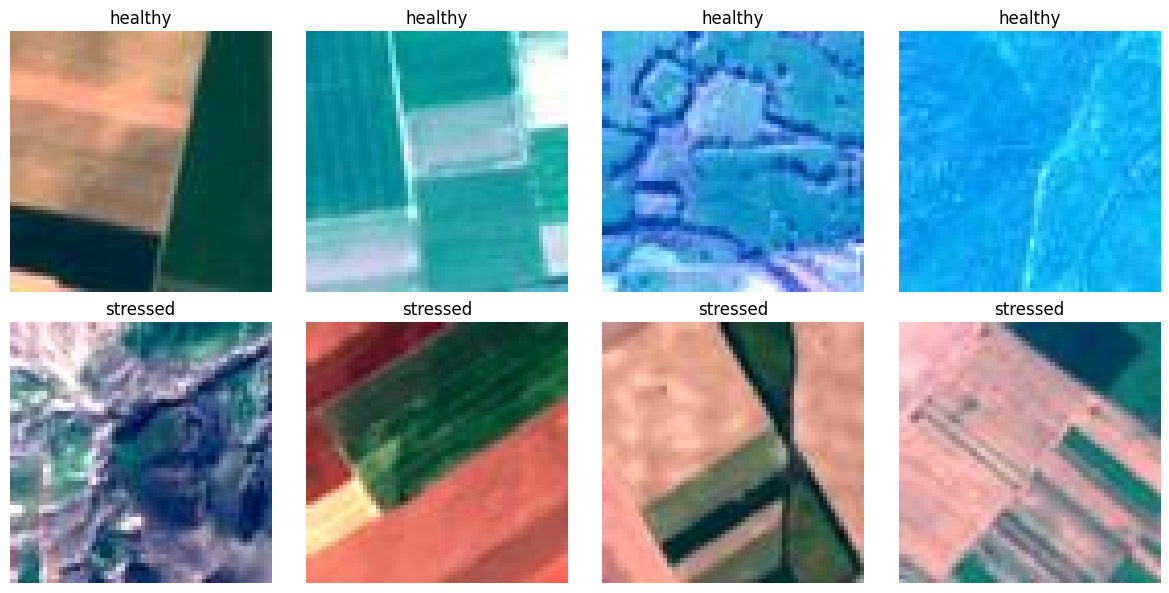

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for row, label in enumerate(["healthy", "stressed"]):
    files = list((root/"train"/label).glob("*.jpg"))
    for col, f in enumerate(random.sample(files, min(4, len(files)))):
        axes[row, col].imshow(Image.open(f))
        axes[row, col].set_title(label)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()


## 6. Train the latest released Ultralytics YOLO model

We use **YOLO26n-cls**:
- `26` = current released YOLO generation
- `n` = nano, the smallest model
- `cls` = image classification

For a classroom demo, start with **10 epochs**. Increase to 20–50 for a stronger experiment.


In [6]:
model = YOLO("yolo26n-cls.pt")

train_results = model.train(
    data=str(root),
    epochs=10,
    imgsz=224,
    batch=32,
    device=0,       # GPU in Colab
    project="/content/runs",
    name="vegetation_stress"
)


Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vegetation_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vegetation_stress, nbs=64, nms=None, opset=N

## 7. Evaluate the model

In [8]:
best_model = YOLO("/content/runs/vegetation_stress/weights/best.pt")

metrics = best_model.val(data=str(root), split="test")
print(f"Top-1 Accuracy: {metrics.top1:.4f}")

# Access the confusion matrix
cm = metrics.confusion_matrix.matrix

# Calculate per-class precision, recall, and F1-score
# cm[0,0] = True Negatives (TN) - stressed correctly predicted as stressed
# cm[0,1] = False Positives (FP) - healthy incorrectly predicted as stressed
# cm[1,0] = False Negatives (FN) - stressed incorrectly predicted as healthy
# cm[1,1] = True Positives (TP) - healthy correctly predicted as healthy

# Assuming class 0 is 'stressed' and class 1 is 'healthy' based on training output.
# Ultralytics typically orders classes alphabetically or by occurrence.
# We can confirm by checking metrics.confusion_matrix.names

class_names = metrics.confusion_matrix.names

# For 'stressed' class (let's assume index 0 based on confusion matrix visual output)
# True Negatives (stressed correctly classified as stressed) are cm[0,0]
# False Positives (healthy incorrectly classified as stressed) are cm[1,0]
# False Negatives (stressed incorrectly classified as healthy) are cm[0,1]
# No, this is standard sklearn style: cm[true_label, predicted_label]
# So if class 0 is 'stressed' and class 1 is 'healthy':
# cm[0,0] = True Negative (stressed -> stressed)
# cm[0,1] = False Positive (healthy -> stressed) (actually False Negative for healthy, but from 'stressed' perspective it's FP)
# Let's use the definition based on positive class.

# Let's consider 'healthy' as the positive class (index 1)
TP_healthy = cm[1, 1]
FP_healthy = cm[0, 1] # Stressed misclassified as Healthy
FN_healthy = cm[1, 0] # Healthy misclassified as Stressed

precision_healthy = TP_healthy / (TP_healthy + FP_healthy) if (TP_healthy + FP_healthy) > 0 else 0
recall_healthy = TP_healthy / (TP_healthy + FN_healthy) if (TP_healthy + FN_healthy) > 0 else 0
f1_healthy = 2 * (precision_healthy * recall_healthy) / (precision_healthy + recall_healthy) if (precision_healthy + recall_healthy) > 0 else 0

# Let's consider 'stressed' as the positive class (index 0)
TP_stressed = cm[0, 0]
FP_stressed = cm[1, 0] # Healthy misclassified as Stressed
FN_stressed = cm[0, 1] # Stressed misclassified as Healthy

precision_stressed = TP_stressed / (TP_stressed + FP_stressed) if (TP_stressed + FP_stressed) > 0 else 0
recall_stressed = TP_stressed / (TP_stressed + FN_stressed) if (TP_stressed + FN_stressed) > 0 else 0
f1_stressed = 2 * (precision_stressed * recall_stressed) / (precision_stressed + recall_stressed) if (precision_stressed + recall_stressed) > 0 else 0

print(f"\nMetrics for '{class_names[1]}':")
print(f"  Precision: {precision_healthy:.4f}")
print(f"  Recall:    {recall_healthy:.4f}")
print(f"  F1-Score:  {f1_healthy:.4f}")

print(f"\nMetrics for '{class_names[0]}':")
print(f"  Precision: {precision_stressed:.4f}")
print(f"  Recall:    {recall_stressed:.4f}")
print(f"  F1-Score:  {f1_stressed:.4f}")


Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/vegetation_dataset/train... found 2800 images in 2 classes ✅ 
val: /content/vegetation_dataset/val... found 600 images in 2 classes ✅ 
test: /content/vegetation_dataset/test... found 600 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 63.4±23.6 MB/s, size: 1.6 KB)
test: Scanning /content/vegetation_dataset/test... 600 images, 0 corrupt: 100% ━━━━━━━━━━━━ 600/600 139.8Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 38/38 16.7it/s 2.3s
                   all      0.962          1
Speed: 0.4ms preprocess, 2.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val-2
Top-1 Accuracy: 0.9617

Metrics for 'stressed':
  Precision: 0.9585
  Recall:    0.9618
  F1-Score:  0.9601

Metrics for 'healthy':
  Precision: 0.964

### Evaluation metrics to report

For this binary classification project, report:
- **Top-1 accuracy**
- **Recall**
- **Precision**
- **F1-score**
- Example successful prediction
- Example failure case

Ultralytics saves training/validation plots in the run folder.

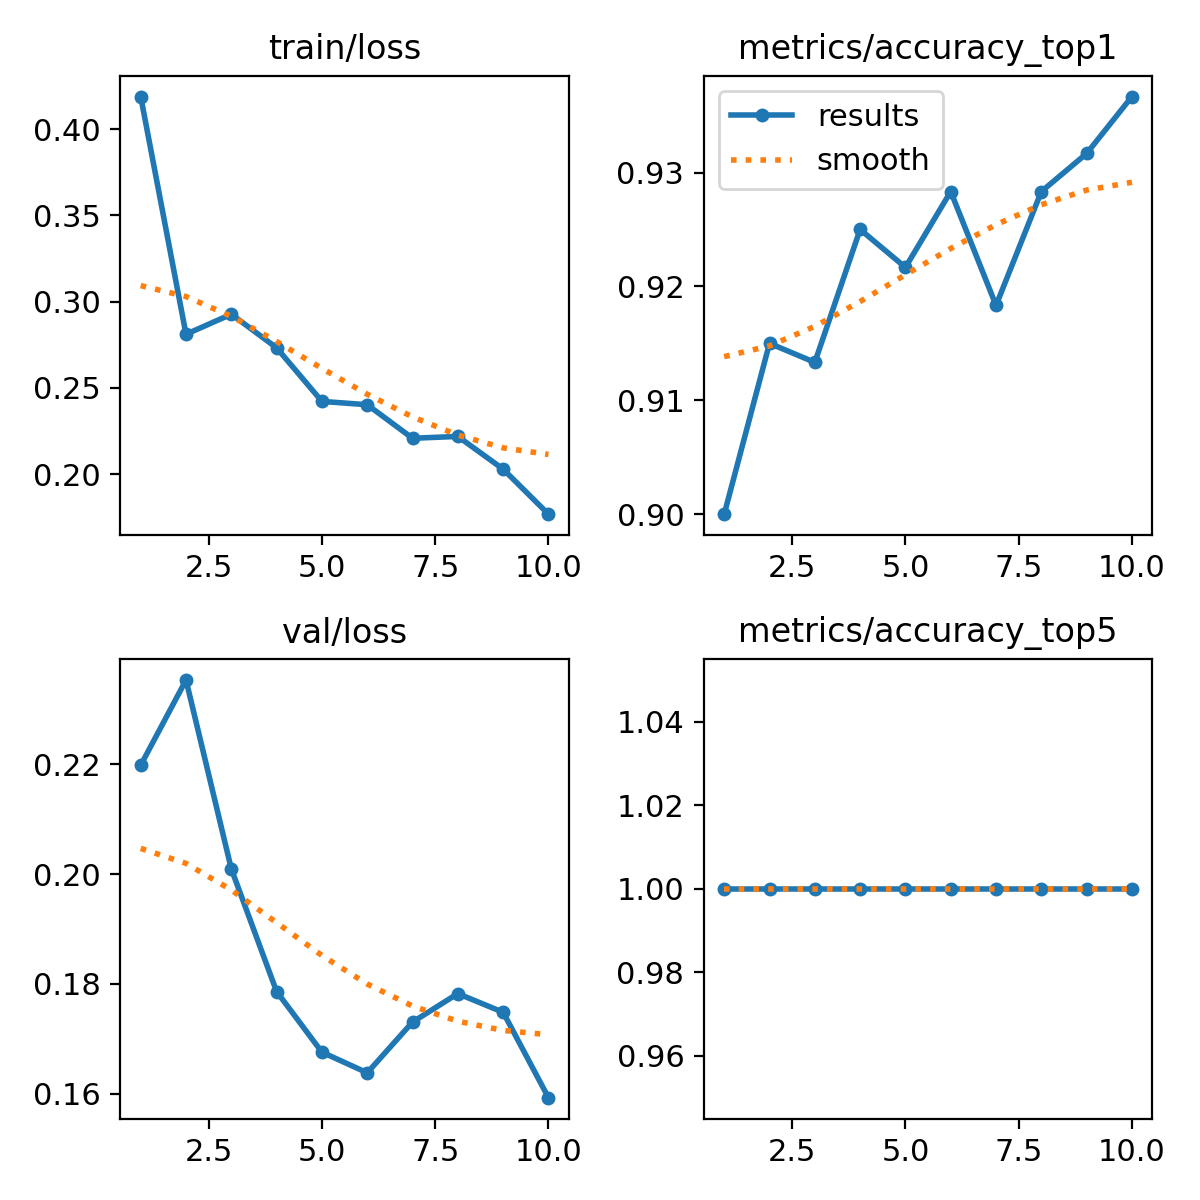

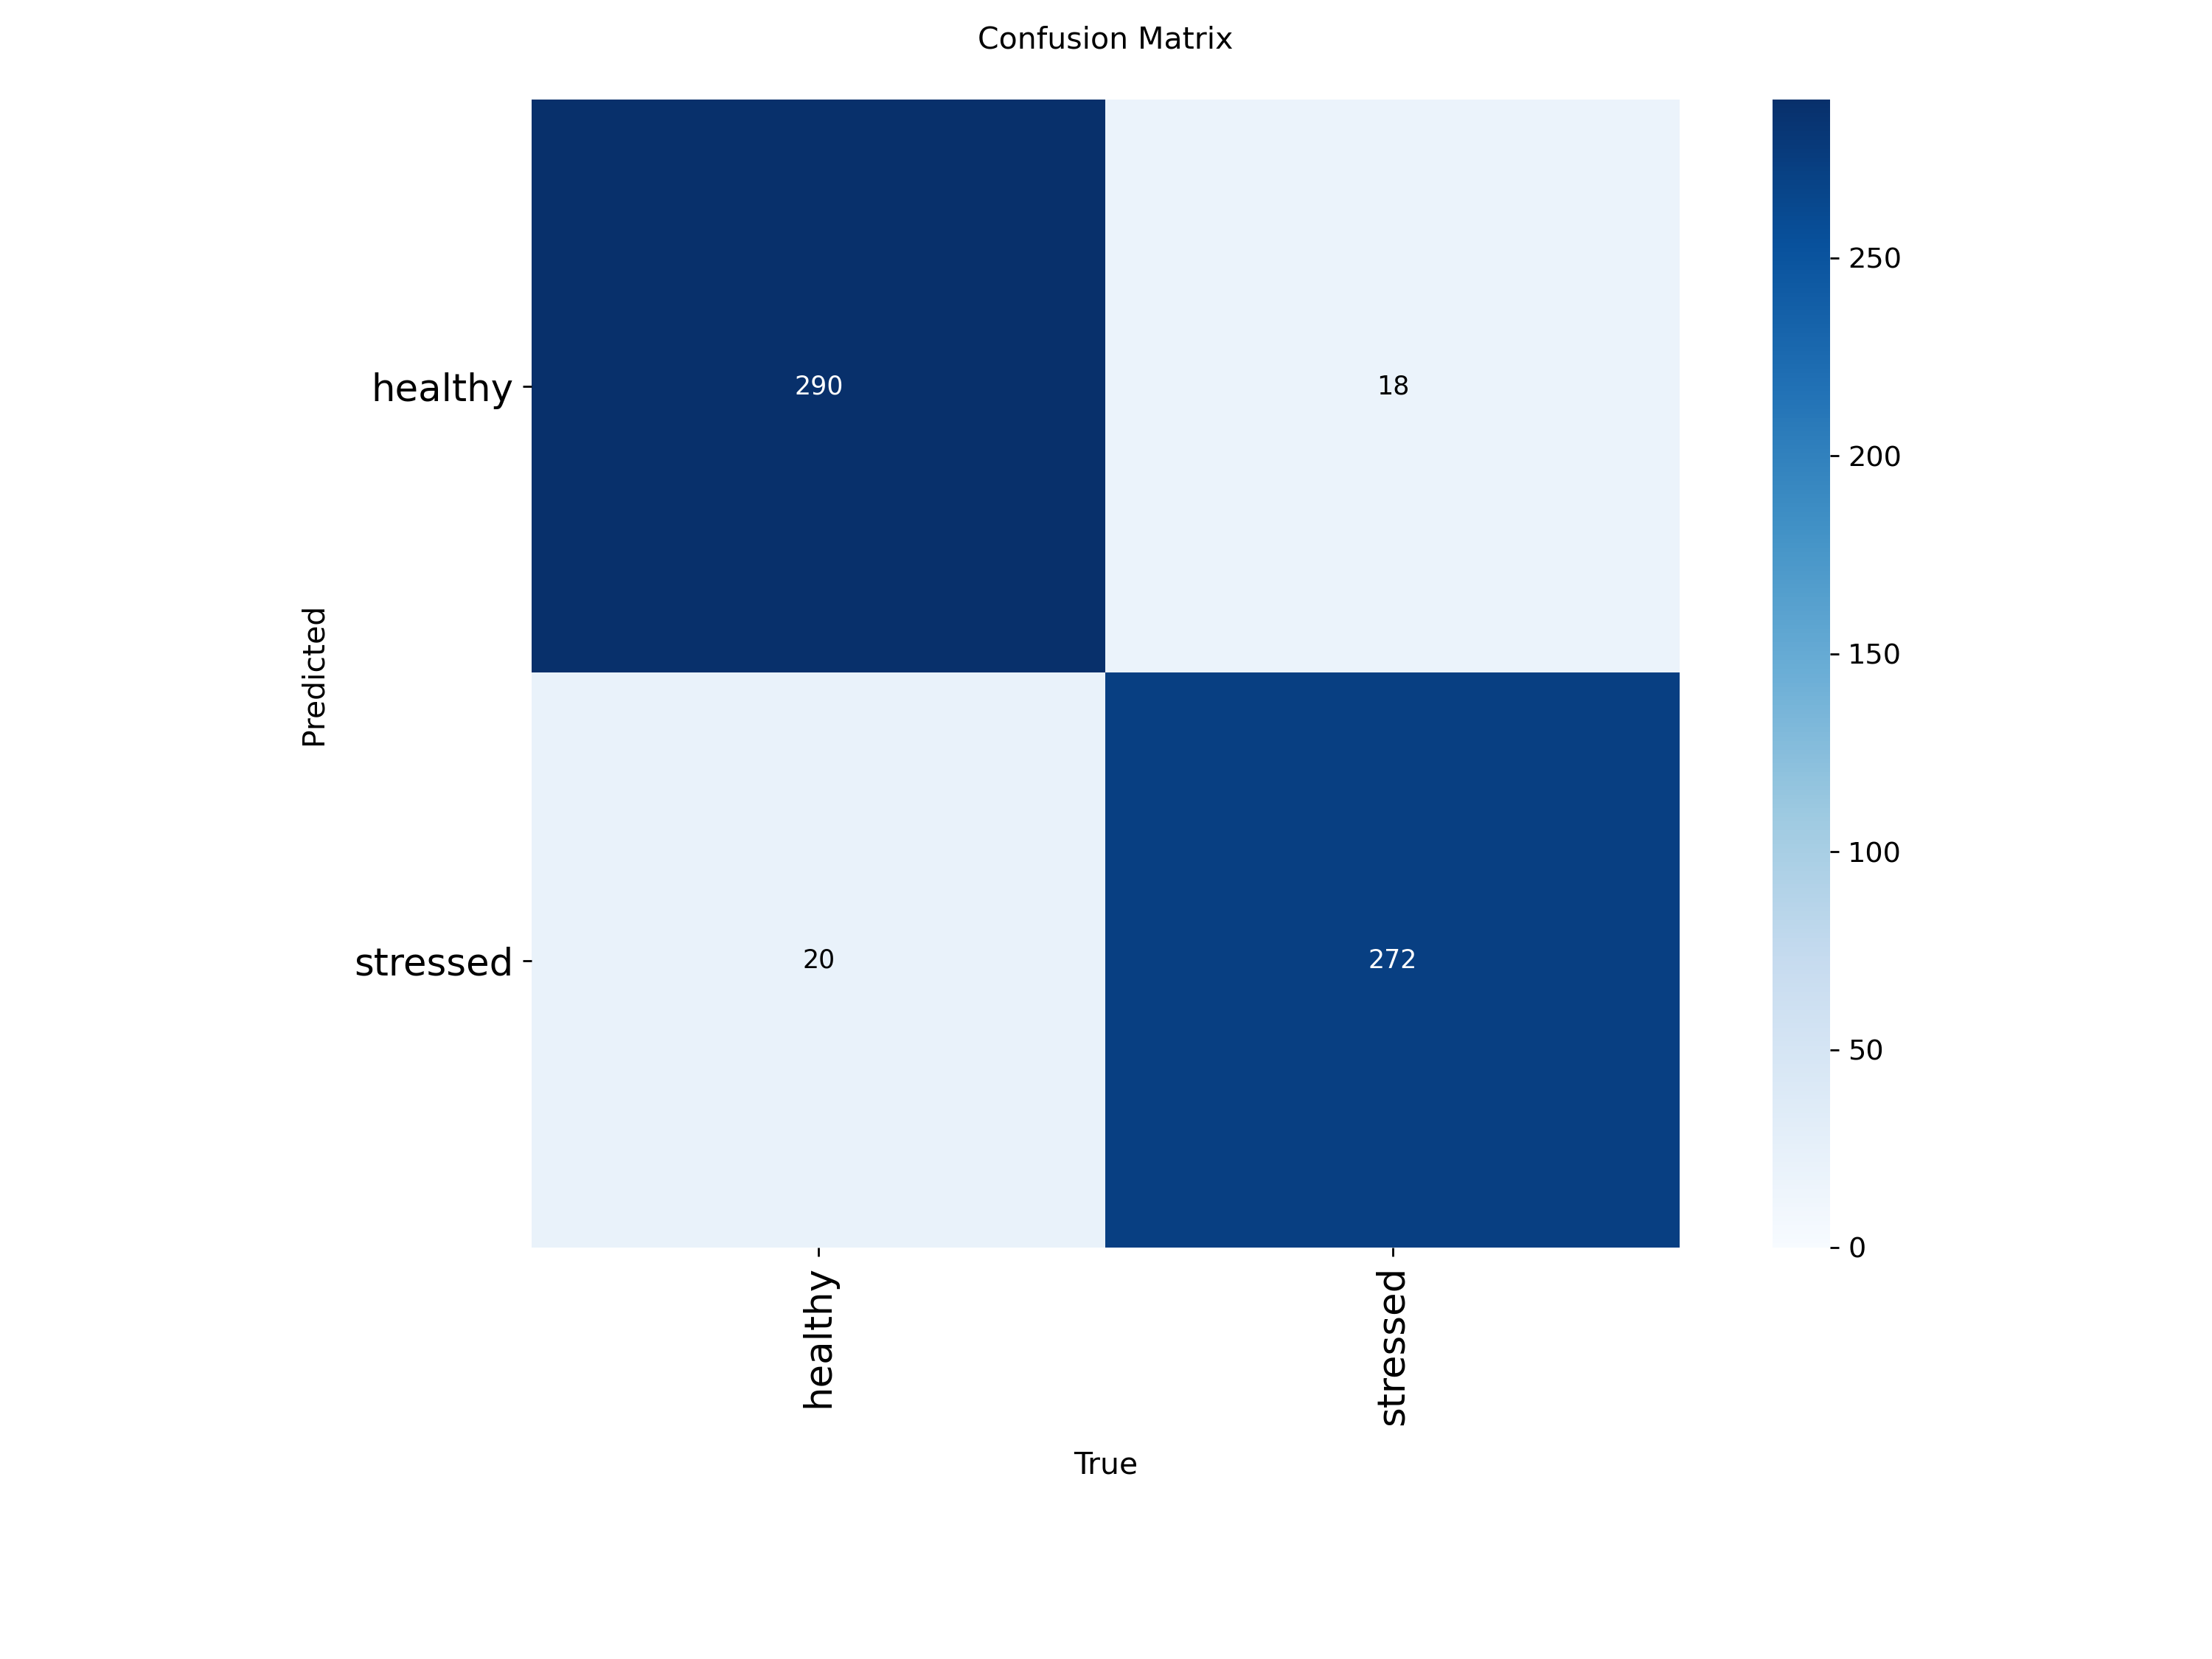

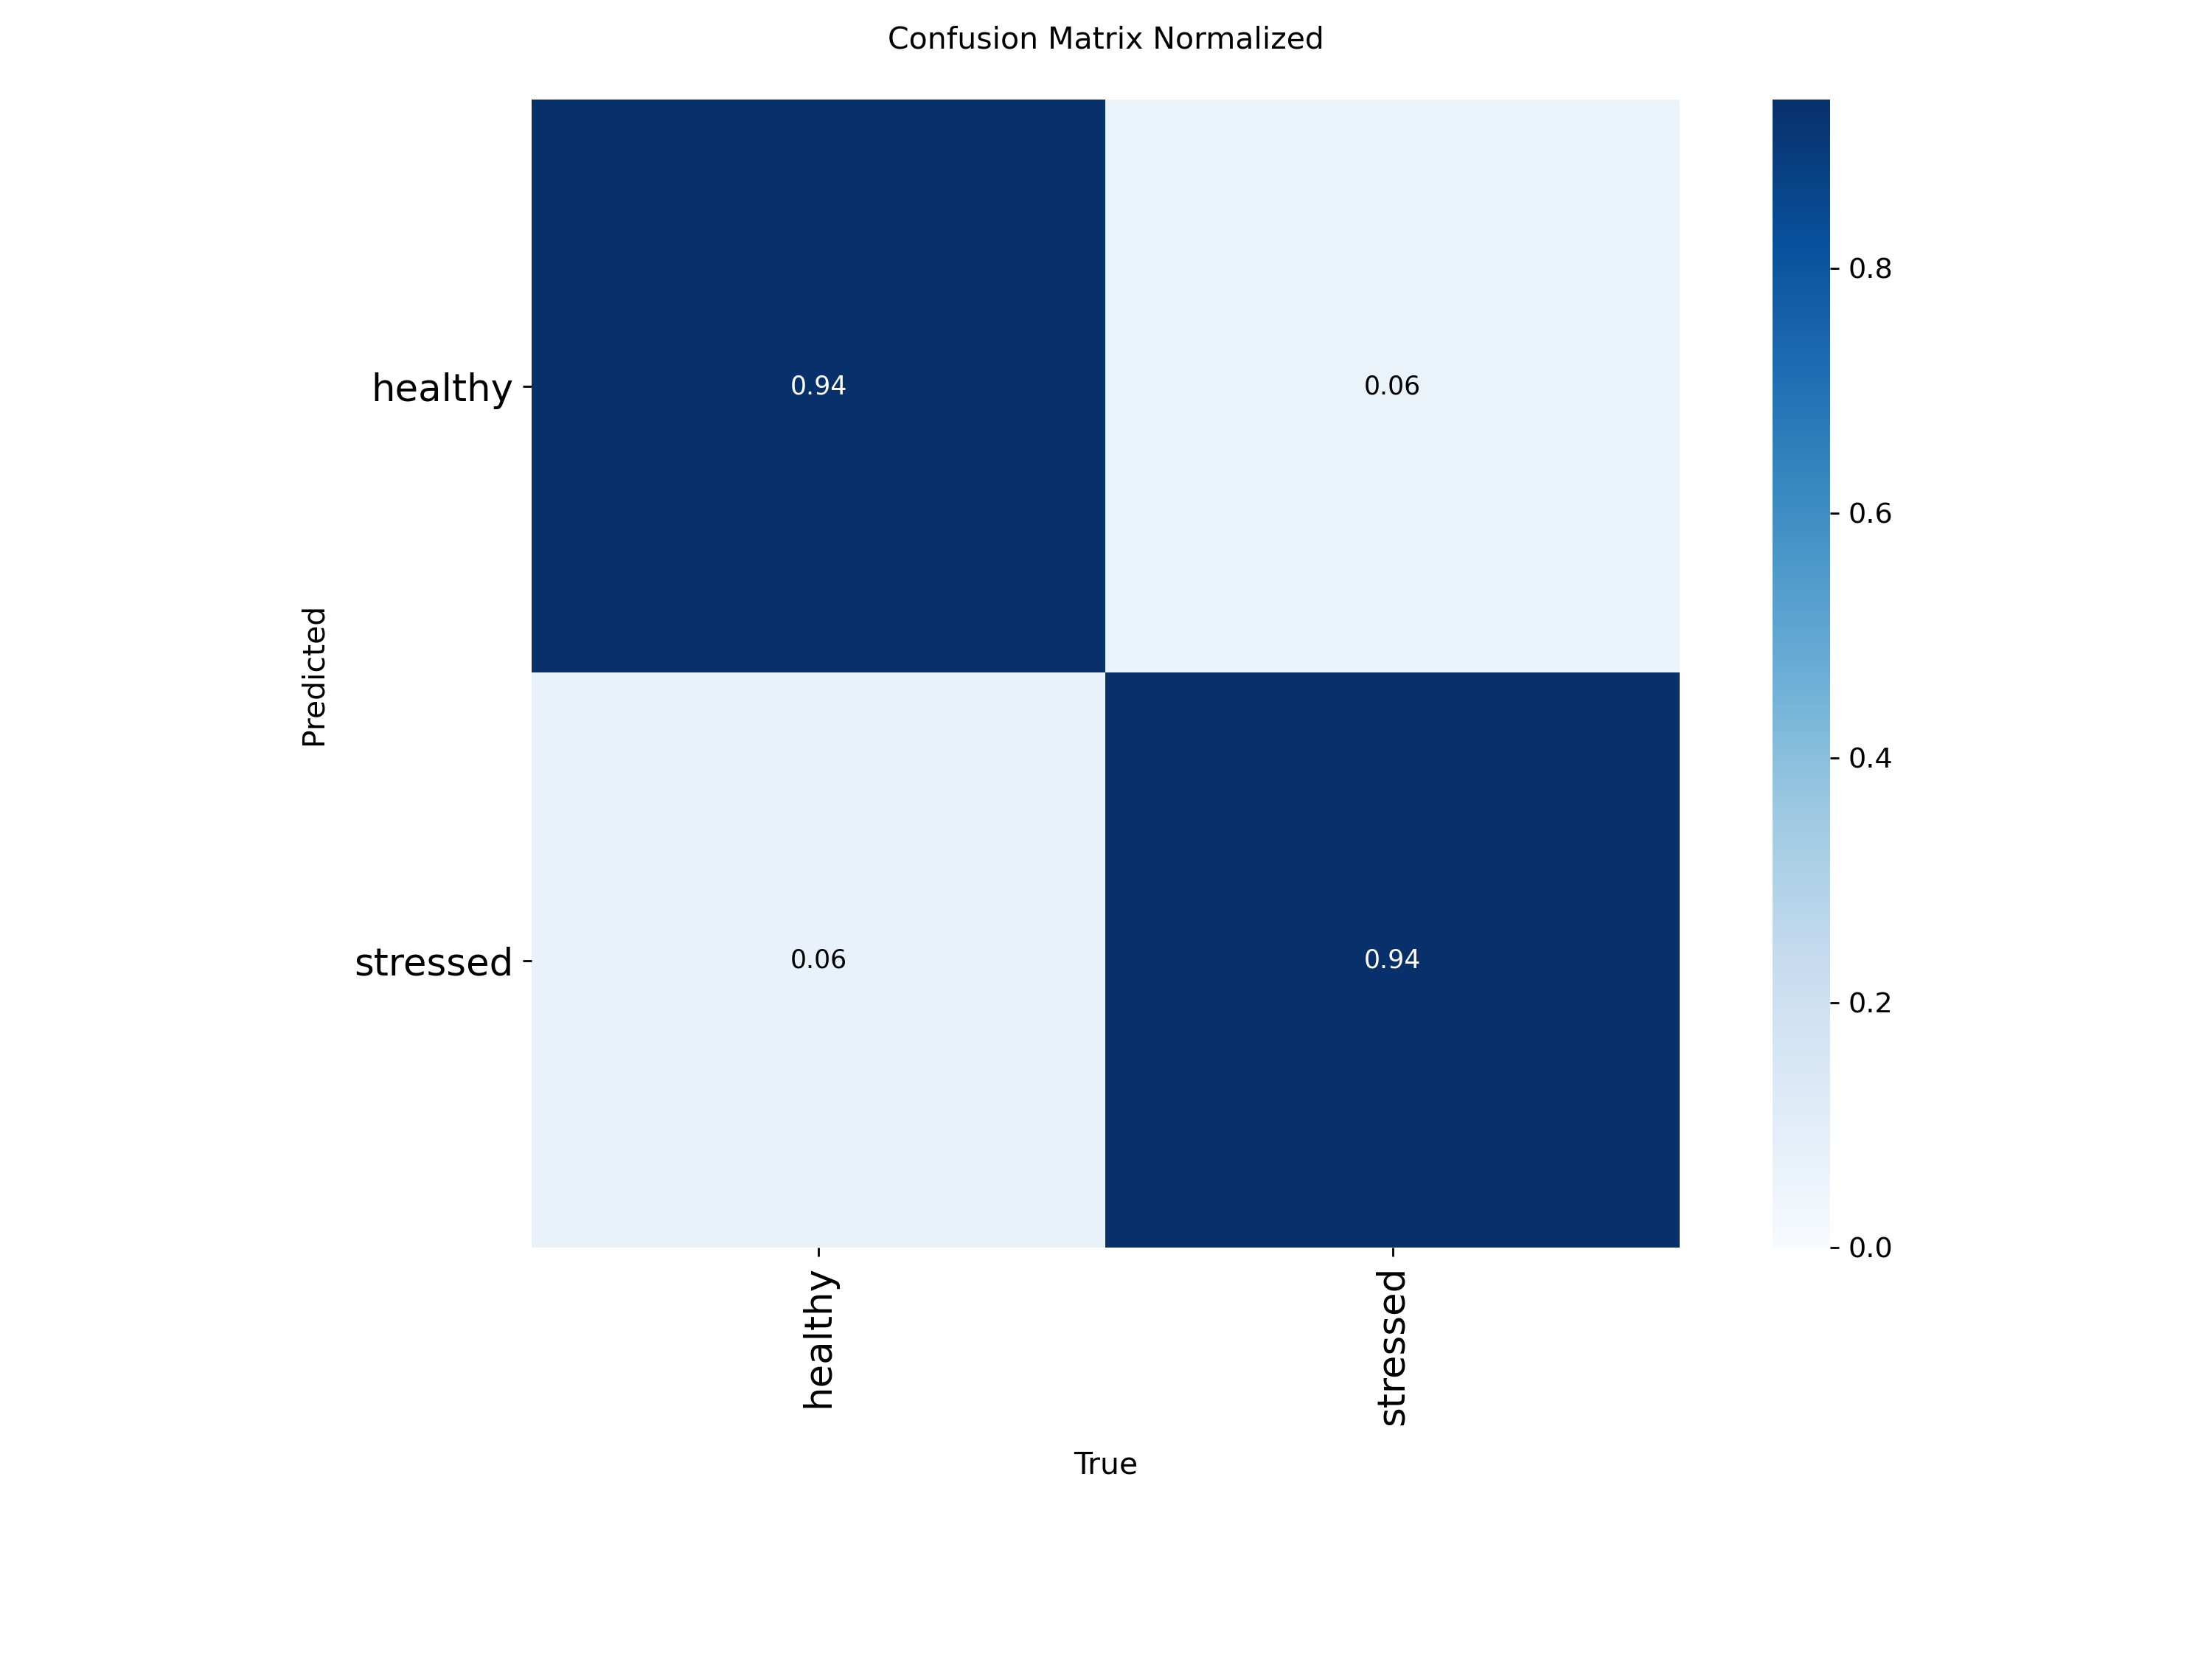

In [9]:
# Show result images generated by Ultralytics, if available
run_dir = Path("/content/runs/vegetation_stress")

for name in ["results.png", "confusion_matrix.png", "confusion_matrix_normalized.png"]:
    p = run_dir / name
    if p.exists():
        display(Image.open(p))


## 8. Make predictions and find a success + failure case

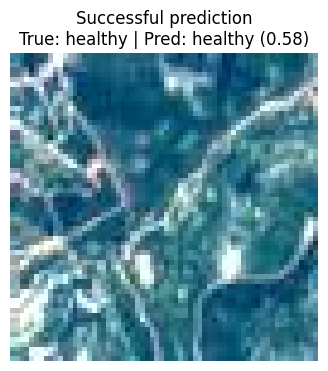

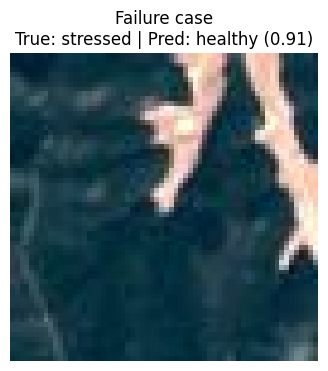

In [10]:
test_files = list((root/"test"/"healthy").glob("*.jpg")) + list((root/"test"/"stressed").glob("*.jpg"))
random.shuffle(test_files)

success = None
failure = None

for f in test_files:
    true_label = f.parent.name
    result = best_model.predict(str(f), verbose=False)[0]
    pred_id = int(result.probs.top1)
    pred_label = result.names[pred_id]
    conf = float(result.probs.top1conf)

    item = (f, true_label, pred_label, conf)

    if pred_label == true_label and success is None:
        success = item
    if pred_label != true_label and failure is None:
        failure = item
    if success and failure:
        break

def show_case(item, title):
    if item is None:
        print(title, ": not found in checked test images.")
        return
    f, true_label, pred_label, conf = item
    plt.figure(figsize=(4,4))
    plt.imshow(Image.open(f))
    plt.axis("off")
    plt.title(f"{title}\nTrue: {true_label} | Pred: {pred_label} ({conf:.2f})")
    plt.show()

show_case(success, "Successful prediction")
show_case(failure, "Failure case")


## 9. Predict a new image

Upload any RGB satellite crop/vegetation image.  
The model will return **healthy** or **stressed** according to the proxy labels learned in this project.


In [ ]:
from google.colab import files

uploaded = files.upload()
new_image = next(iter(uploaded.keys()))

prediction = best_model.predict(new_image, imgsz=224)
prediction[0].show()


## 10. Export to ONNX

This satisfies the optional deployment/optimization part of the final-project requirements.


In [11]:
best_model.export(format="onnx", imgsz=224)


Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO26n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 0.4 GFLOPs

PyTorch: starting from '/content/runs/vegetation_stress/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 2) (3.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 232ms
Prepared 4 packages in 958ms
Installed 4 packages in 273ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.30.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 1.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming 

'/content/runs/vegetation_stress/weights/best.onnx'

## 11. Real-application idea

A simple real system could:

1. Receive a new Sentinel-2 image patch.
2. Convert the required bands to RGB.
3. Run the trained YOLO26 classifier.
4. Display **healthy** or **stressed** with confidence.
5. Flag stressed regions for inspection by an agronomist.

### Failure cases / limitations
- NDVI is only a **proxy** for vegetation condition.
- Low NDVI can be caused by sparse vegetation, soil, crop stage, clouds, shadows, or harvest — not only stress.
- EuroSAT was created for **land-cover classification**, not crop-stress diagnosis.
- A stronger final system should use field-validated stress labels, multiple dates, and multispectral bands directly.

### Future improvements
- Use true ground-truth crop-stress labels.
- Add temporal Sentinel-2 observations.
- Use NDVI, NDMI, red-edge and SWIR bands.
- Compare YOLO26 with a multispectral CNN.
- Train on more images and more epochs.
